In [ ]:
!pip install mne
!pip install git+https://github.com/forrestbao/pyeeg.git
!pip install antropy
!pip install SciPy

  Cloning https://github.com/forrestbao/pyeeg.git to /tmp/pip-req-build-wzwcfjk1
  Running command git clone --filter=blob:none --quiet https://github.com/forrestbao/pyeeg.git /tmp/pip-req-build-wzwcfjk1
  Resolved https://github.com/forrestbao/pyeeg.git to commit a6c18bb093e4748f9d9c208535a6ae024a0802b8
  Preparing metadata (setup.py) ... done


In [ ]:
from glob import glob
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
import glob
import os

base_directory = '/content/drive/MyDrive/Colab Notebooks/Research/Emotiv 30s EDF'

test_directory = os.path.join(base_directory, 'Test')
train_directory = os.path.join(base_directory, 'Train')

# Get EDF files from the Test directory
test_edf_files = sorted(glob.glob(os.path.join(test_directory, '**/*.edf'), recursive=True))
print(f"Found {len(test_edf_files)} EDF files in the Test directory.")

# Get EDF files from the Train directory
train_edf_files = sorted(glob.glob(os.path.join(train_directory, '**/*.edf'), recursive=True))
print(f"Found {len(train_edf_files)} EDF files in the Train directory.")

# You can now process test_edf_files and train_edf_files separately.
# For example, to just show the first few files from each:
print("\nFirst 5 test EDF files:")
for f in test_edf_files[:5]:
    print(f)

print("\nFirst 5 train EDF files:")
for f in train_edf_files[:5]:
    print(f)

Found 20 EDF files in the Test directory.
Found 100 EDF files in the Train directory.

First 5 test EDF files:
/content/drive/MyDrive/Colab Notebooks/Research/Emotiv 30s EDF/Test/S003/S003E01.edf
/content/drive/MyDrive/Colab Notebooks/Research/Emotiv 30s EDF/Test/S003/S003E02.edf
/content/drive/MyDrive/Colab Notebooks/Research/Emotiv 30s EDF/Test/S003/S003E03.edf
/content/drive/MyDrive/Colab Notebooks/Research/Emotiv 30s EDF/Test/S003/S003E04.edf
/content/drive/MyDrive/Colab Notebooks/Research/Emotiv 30s EDF/Test/S010/S010E01.edf

First 5 train EDF files:
/content/drive/MyDrive/Colab Notebooks/Research/Emotiv 30s EDF/Train/S001/S001E01.edf
/content/drive/MyDrive/Colab Notebooks/Research/Emotiv 30s EDF/Train/S001/S001E02.edf
/content/drive/MyDrive/Colab Notebooks/Research/Emotiv 30s EDF/Train/S001/S001E03.edf
/content/drive/MyDrive/Colab Notebooks/Research/Emotiv 30s EDF/Train/S001/S001E04.edf
/content/drive/MyDrive/Colab Notebooks/Research/Emotiv 30s EDF/Train/S002/S002E01.edf


In [ ]:
filtered_test_signals = []
print(f"Re-applying band-pass filtering for {len(test_edf_files)} test files...")
for i, file_path in enumerate(test_edf_files):
    temp_raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
    temp_raw.filter(l_freq=1, h_freq=40.0, verbose=False)
    filtered_test_signals.append(temp_raw)
    if (i + 1) % 10 == 0: print(f"Filtered {i + 1}/{len(test_edf_files)} test files...")

filtered_train_signals = []
print(f"\nRe-applying band-pass filtering for {len(train_edf_files)} train files...")
for i, file_path in enumerate(train_edf_files):
    temp_raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
    temp_raw.filter(l_freq=1, h_freq=40.0, verbose=False)
    filtered_train_signals.append(temp_raw)
    if (i + 1) % 20 == 0: print(f"Filtered {i + 1}/{len(train_edf_files)} train files...")

print("\nBand-pass filtering complete for both test and train datasets.")

Re-applying band-pass filtering for 20 test files...


/tmp/ipykernel_2406/3905900752.py:4: RuntimeWarning: Physical range is not defined in following channels:
P8
  temp_raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
/tmp/ipykernel_2406/3905900752.py:4: RuntimeWarning: Physical range is not defined in following channels:
P8
  temp_raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


Filtered 10/20 test files...


/tmp/ipykernel_2406/3905900752.py:4: RuntimeWarning: Physical range is not defined in following channels:
P8
  temp_raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
/tmp/ipykernel_2406/3905900752.py:4: RuntimeWarning: Physical range is not defined in following channels:
P8
  temp_raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
/tmp/ipykernel_2406/3905900752.py:4: RuntimeWarning: Physical range is not defined in following channels:
P8
  temp_raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


Filtered 20/20 test files...

Re-applying band-pass filtering for 100 train files...


...

Filtered 60/100 train files...


/tmp/ipykernel_2406/3905900752.py:12: RuntimeWarning: Physical range is not defined in following channels:
P8
  temp_raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


Filtered 80/100 train files...


/tmp/ipykernel_2406/3905900752.py:12: RuntimeWarning: Physical range is not defined in following channels:
P8
  temp_raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
/tmp/ipykernel_2406/3905900752.py:12: RuntimeWarning: Physical range is not defined in following channels:
P8
  temp_raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
/tmp/ipykernel_2406/3905900752.py:12: RuntimeWarning: Physical range is not defined in following channels:
P8
  temp_raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
/tmp/ipykernel_2406/3905900752.py:12: RuntimeWarning: Physical range is not defined in following channels:
P8
  temp_raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
/tmp/ipykernel_2406/3905900752.py:12: RuntimeWarning: Physical range is not defined in following channels:
P8
  temp_raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
/tmp/ipykernel_2406/3905900752.py:12: RuntimeWarning: Physical range is not defined i

Filtered 100/100 train files...

Band-pass filtering complete for both test and train datasets.


In [ ]:
# Define a function to apply a notch filter
def apply_notch_filter(raw_list, notch_freq=50.0, dataset_name="signals"):
    notched_signals = []
    print(f"Starting notch filtering at {notch_freq} Hz for {len(raw_list)} {dataset_name}...")
    for i, raw_temp in enumerate(raw_list):
        # Apply the notch filter
        raw_temp.notch_filter(freqs=notch_freq, verbose=False)
        notched_signals.append(raw_temp)

        if (i + 1) % 10 == 0:
            print(f"Processed {i + 1}/{len(raw_list)} {dataset_name}...")

    print(f"\nFinished applying notch filter to all {dataset_name}.")
    return notched_signals

# Apply the notch filter to the previously band-pass filtered test signals
notched_test_signals = apply_notch_filter(filtered_test_signals, dataset_name="test signals")
print(f"Total test signals after notch filtering: {len(notched_test_signals)}")

# Apply the notch filter to the previously band-pass filtered train signals
notched_train_signals = apply_notch_filter(filtered_train_signals, dataset_name="train signals")
print(f"Total train signals after notch filtering: {len(notched_train_signals)}")

Starting notch filtering at 50.0 Hz for 20 test signals...
Processed 10/20 test signals...
Processed 20/20 test signals...

Finished applying notch filter to all test signals.
Total test signals after notch filtering: 20
Starting notch filtering at 50.0 Hz for 100 train signals...
Processed 10/100 train signals...
Processed 20/100 train signals...
Processed 30/100 train signals...
Processed 40/100 train signals...
Processed 50/100 train signals...
Processed 60/100 train signals...
Processed 70/100 train signals...
Processed 80/100 train signals...
Processed 90/100 train signals...
Processed 100/100 train signals...

Finished applying notch filter to all train signals.
Total train signals after notch filtering: 100


In [ ]:
def apply_car(raw_list, dataset_name):
    car_signals = []
    print(f"Starting Common Average Referencing (CAR) for {len(raw_list)} {dataset_name}...")
    for i, raw_obj in enumerate(raw_list):
        raw_car = raw_obj.copy()
        raw_car.set_eeg_reference('average', verbose=False)
        car_signals.append(raw_car)

        if (i + 1) % 10 == 0:
            print(f"Re-referencing processed for {i + 1}/{len(raw_list)} {dataset_name}...")

    print(f"\nFinished applying Common Average Referencing to {dataset_name}.")
    print(f"Total signals after CAR on {dataset_name}: {len(car_signals)}")
    return car_signals

# Apply CAR to notched test signals
notched_test_signals_car = apply_car(notched_test_signals, "notched test signals")

# Apply CAR to notched train signals
notched_train_signals_car = apply_car(notched_train_signals, "notched train signals")

Starting Common Average Referencing (CAR) for 20 notched test signals...
Re-referencing processed for 10/20 notched test signals...
Re-referencing processed for 20/20 notched test signals...

Finished applying Common Average Referencing to notched test signals.
Total signals after CAR on notched test signals: 20
Starting Common Average Referencing (CAR) for 100 notched train signals...
Re-referencing processed for 10/100 notched train signals...
Re-referencing processed for 20/100 notched train signals...
Re-referencing processed for 30/100 notched train signals...
Re-referencing processed for 40/100 notched train signals...
Re-referencing processed for 50/100 notched train signals...
Re-referencing processed for 60/100 notched train signals...
Re-referencing processed for 70/100 notched train signals...
Re-referencing processed for 80/100 notched train signals...
Re-referencing processed for 90/100 notched train signals...
Re-referencing processed for 100/100 notched train signals...


In [ ]:
from mne.preprocessing import ICA

def apply_ica(raw_list, dataset_name, exclude_idx=[0, 1]):
    cleaned_signals = []
    print(f"Restoring {dataset_name} via ICA...")
    for i, raw_car_signal in enumerate(raw_list):
        # No need to notch filter again, as it was done in the previous step
        ica = ICA(n_components=0.999, max_iter='auto', random_state=97)
        ica.fit(raw_car_signal, verbose=False)
        raw_cleaned = raw_car_signal.copy()
        ica.exclude = exclude_idx
        ica.apply(raw_cleaned, verbose=False)
        cleaned_signals.append(raw_cleaned)
        if (i + 1) % 10 == 0: print(f"ICA complete for {i + 1}/{len(raw_list)} {dataset_name}...")
    print(f"\nFinished applying ICA to {dataset_name}.")
    return cleaned_signals

# Apply ICA to the test dataset
cleaned_test_signals_ica = apply_ica(notched_test_signals_car, "test signals")

# Apply ICA to the train dataset
cleaned_train_signals_ica = apply_ica(notched_train_signals_car, "train signals")

Restoring test signals via ICA...
ICA complete for 10/20 test signals...
ICA complete for 20/20 test signals...

Finished applying ICA to test signals.
Restoring train signals via ICA...
ICA complete for 10/100 train signals...
ICA complete for 20/100 train signals...
ICA complete for 30/100 train signals...
ICA complete for 40/100 train signals...
ICA complete for 50/100 train signals...
ICA complete for 60/100 train signals...
ICA complete for 70/100 train signals...
ICA complete for 80/100 train signals...
ICA complete for 90/100 train signals...
ICA complete for 100/100 train signals...

Finished applying ICA to train signals.


In [ ]:
import numpy as np

def check_nan_inf(signals_list, dataset_name):
    nan_found = False
    inf_found = False

    print(f"Checking {dataset_name} for NaN or Inf values...")
    for i, raw in enumerate(signals_list):
        data = raw.get_data()
        if np.isnan(data).any():
            print(f"NaN detected in {dataset_name} signal index {i}")
            nan_found = True
        if np.isinf(data).any():
            print(f"Inf detected in {dataset_name} signal index {i}")
            inf_found = True

    if not nan_found and not inf_found:
        print(f"Data check passed: No NaN or Inf values found in the cleaned {dataset_name}.")
    else:
        print(f"Data check failed: NaN or Inf values were detected in the {dataset_name}.")
    return nan_found or inf_found

# Check cleaned test signals
test_issues = check_nan_inf(cleaned_test_signals_ica, "test signals")

# Check cleaned train signals
train_issues = check_nan_inf(cleaned_train_signals_ica, "train signals")

if not test_issues and not train_issues:
    print("\nOverall data check passed: No NaN or Inf values found in any cleaned signals.")
else:
    print("\nOverall data check failed: NaN or Inf values were detected in some cleaned signals.")

Checking test signals for NaN or Inf values...
Data check passed: No NaN or Inf values found in the cleaned test signals.
Checking train signals for NaN or Inf values...
Data check passed: No NaN or Inf values found in the cleaned train signals.

Overall data check passed: No NaN or Inf values found in any cleaned signals.


In [ ]:
import pandas as pd
import numpy as np

def segment_signals(cleaned_signals, edf_file_paths, dataset_name):
    sfreq = cleaned_signals[0].info['sfreq']
    segment_duration_seconds = 60
    samples_per_segment = int(sfreq * segment_duration_seconds)

    segmented_data_list = []

    print(f"Segmenting {len(cleaned_signals)} {dataset_name} into 60-second intervals...")

    for i, raw in enumerate(cleaned_signals):
        data = raw.get_data() # channels x samples
        file_name = edf_file_paths[i].split('/')[-1]

        # Ensure the signal is at least 3 * segment_duration_seconds long (180 seconds)
        if raw.n_times < 3 * samples_per_segment:
            print(f"Skipping file {file_name}: signal too short ({raw.n_times / sfreq:.1f}s) for 3 segments.")
            continue

        # Calculate start and end samples for each of the three original segments
        start_low_1 = 0
        end_low_1 = samples_per_segment

        start_high = samples_per_segment
        end_high = 2 * samples_per_segment

        start_low_2 = raw.n_times - samples_per_segment
        end_low_2 = raw.n_times

        for ch_idx, ch_name in enumerate(raw.ch_names):
            # Extract the first and last 60-second 'Low Concentration' parts
            segment_1_low_conc = data[ch_idx, start_low_1:end_low_1]
            segment_3_low_conc = data[ch_idx, start_low_2:end_low_2]

            # Concatenate them into a single 120-second 'Low Concentration' segment
            combined_low_concentration_segment = np.concatenate((segment_1_low_conc, segment_3_low_conc))
            segmented_data_list.append({
                'File': file_name,
                'Channel': ch_name,
                'Segment_Type': 'Low Concentration',
                'Segment_Index': 0, # Assign new index 0 for combined Low Concentration
                'Data': combined_low_concentration_segment,
                'Duration_s': 2 * segment_duration_seconds # Duration is now 120 seconds
            })

            # Extract the middle 60-second 'High Concentration' segment
            segment_2_high_conc = data[ch_idx, start_high:end_high]
            segmented_data_list.append({
                'File': file_name,
                'Channel': ch_name,
                'Segment_Type': 'High Concentration',
                'Segment_Index': 1, # Assign new index 1 for High Concentration
                'Data': segment_2_high_conc,
                'Duration_s': segment_duration_seconds
            })

        if (i + 1) % 20 == 0:
            print(f"Processed {i + 1}/{len(cleaned_signals)} {dataset_name}...")

    segmented_df = pd.DataFrame(segmented_data_list)
    print(f"\nSegmentation complete for {dataset_name}.")
    print(f"Total segments created for {dataset_name}: {len(segmented_df)}")
    return segmented_df

# Segment the test signals
segmented_test_df = segment_signals(cleaned_test_signals_ica, test_edf_files, "test signals")
display(segmented_test_df.head())

# Segment the train signals
segmented_train_df = segment_signals(cleaned_train_signals_ica, train_edf_files, "train signals")
display(segmented_train_df.head())

Segmenting 20 test signals into 60-second intervals...
Processed 20/20 test signals...

Segmentation complete for test signals.
Total segments created for test signals: 560


,File,Channel,Segment_Type,Segment_Index,Data,Duration_s
0,S003E01.edf,AF3,Low Concentration,0,"[-8.075113910298484e-09, -1.087025225014779e-0...",120
1,S003E01.edf,AF3,High Concentration,1,"[1.0972203952824955e-06, 4.971652008102777e-06...",60
2,S003E01.edf,F7,Low Concentration,0,"[-7.13517382389611e-09, 7.911542860666736e-07,...",120
3,S003E01.edf,F7,High Concentration,1,"[-5.243895190758629e-06, -5.530881834297316e-0...",60
4,S003E01.edf,F3,Low Concentration,0,"[-6.034281675326208e-09, 2.9687353815933974e-0...",120


Segmenting 100 train signals into 60-second intervals...
Processed 20/100 train signals...
Processed 40/100 train signals...
Processed 60/100 train signals...
Processed 80/100 train signals...
Processed 100/100 train signals...

Segmentation complete for train signals.
Total segments created for train signals: 2800


,File,Channel,Segment_Type,Segment_Index,Data,Duration_s
0,S001E01.edf,AF3,Low Concentration,0,"[-1.874696371605581e-08, 2.5063627226421322e-0...",120
1,S001E01.edf,AF3,High Concentration,1,"[-1.6599042545632006e-06, -1.2593779189471898e...",60
2,S001E01.edf,F7,Low Concentration,0,"[-2.946315179501648e-08, -1.982188772958288e-0...",120
3,S001E01.edf,F7,High Concentration,1,"[-8.96831583695802e-06, -9.841560864943247e-06...",60
4,S001E01.edf,F3,Low Concentration,0,"[-7.299903853146405e-09, -4.9540666846216576e-...",120


In [ ]:
import pyeeg
from itertools import chain
import numpy as np

def extract_features(signal):
    aa = pyeeg.bin_power(signal, [0.5, 4, 7, 12, 30], 173)
    power_list = list(aa[0])
    ratio_list = list(aa[1])
    b = [
        [pyeeg.hfd(signal, Kmax=5)],
        [pyeeg.svd_entropy(signal, Tau=4, DE=10)],
        [pyeeg.fisher_info(signal, Tau=4, DE=10)],
        [pyeeg.dfa(signal)]
    ]
    flattened_b = list(chain.from_iterable(b))
    return power_list + ratio_list + flattened_b

if 'final_cleaned_signals' in globals() and len(final_cleaned_signals) > 0:
    test_signal = final_cleaned_signals[0].get_data()[0, :]
    test_features = extract_features(test_signal)
    print("Test Success! Features:", test_features)
else:
    print("Warning: Data not found. Please ensure cells above ran successfully.")

In [ ]:
import pandas as pd
import numpy as np

def process_segments_for_features(segmented_df, dataset_name):
    all_features_list = []

    # Define column names for the 12 features as per the extract_features function in 9_vspq4zvg0Y
    feature_names = [
        'Delta_P', 'Theta_P', 'Alpha_P', 'Beta_P',
        'Delta_R', 'Theta_R', 'Alpha_R', 'Beta_R',
        'HFD', 'SVD_Entropy', 'Fisher_Info', 'DFA'
    ]

    print(f"Extracting features from {len(segmented_df)} segments in {dataset_name}...")

    for i, row in enumerate(segmented_df.itertuples(index=False)):
        signal_data = row.Data
        file_name = row.File
        channel_name = row.Channel
        segment_type = row.Segment_Type
        segment_index = row.Segment_Index

        try:
            # Call extract_features without sfreq, as its current definition in 9_vspq4zvg0Y does not accept it as an argument
            feat_vector = extract_features(signal_data)

            # Create a dictionary for the current row's features
            row_features = {
                'File': file_name,
                'Channel': channel_name,
                'Segment_Type': segment_type,
                'Segment_Index': segment_index
            }
            # Add the 12 extracted features using the defined feature_names
            for j, feature_name in enumerate(feature_names):
                row_features[feature_name] = feat_vector[j]

            all_features_list.append(row_features)
        except Exception as e:
            print(f"Error extracting features for {file_name}, channel {channel_name}, segment type {segment_type}, index {segment_index}: {e}")
            # If an error occurs, append a row with NaNs for features
            row_features = {
                'File': file_name,
                'Channel': channel_name,
                'Segment_Type': segment_type,
                'Segment_Index': segment_index
            }
            for feature_name in feature_names:
                row_features[feature_name] = np.nan
            all_features_list.append(row_features)


        if (i + 1) % 500 == 0:
            print(f"Processed {i+1}/{len(segmented_df)} segments in {dataset_name}...")

    final_df = pd.DataFrame(all_features_list)
    print(f"\nFeature extraction complete for {dataset_name}.")
    print(f"Total features extracted for {dataset_name}: {len(final_df)}")
    return final_df

# Process test segments
final_test_df = process_segments_for_features(segmented_test_df, "test set")
display(final_test_df.head())

# Process train segments
final_train_df = process_segments_for_features(segmented_train_df, "train set")
display(final_train_df.head())

# Optionally save to CSV
# final_test_df.to_csv('pyeeg_processed_test_features.csv', index=False)
# final_train_df.to_csv('pyeeg_processed_train_features.csv', index=False)

# print("Saved processed features for test and train sets to CSV files.")

Extracting features from 560 segments in test set...
Processed 500/560 segments in test set...

Feature extraction complete for test set.
Total features extracted for test set: 560


,File,Channel,Segment_Type,Segment_Index,Delta_P,Theta_P,Alpha_P,Beta_P,Delta_R,Theta_R,Alpha_R,Beta_R,HFD,SVD_Entropy,Fisher_Info,DFA
0,S003E01.edf,AF3,Low Concentration,0,6.793351,2.656377,3.084372,4.001284,0.410837,0.160648,0.186532,0.241983,0.167778,2.011176,2.011176,0.609805
1,S003E01.edf,AF3,High Concentration,1,1.606210,0.606045,0.610110,1.310921,0.388604,0.146625,0.147609,0.317162,0.198013,2.085528,2.085528,0.645205
2,S003E01.edf,F7,Low Concentration,0,4.866510,1.744316,1.640391,4.184799,0.391324,0.140263,0.131906,0.336506,0.217970,1.951157,1.951157,0.746449
3,S003E01.edf,F7,High Concentration,1,1.466292,0.508094,0.516895,1.325198,0.384200,0.133132,0.135438,0.347230,0.224548,2.025562,2.025562,0.836348
4,S003E01.edf,F3,Low Concentration,0,4.211047,2.250250,3.511920,18.089763,0.150057,0.080186,0.125144,0.644613,0.293572,2.262678,2.262678,0.567544


Extracting features from 2800 segments in train set...
Processed 500/2800 segments in train set...
Processed 1000/2800 segments in train set...
Processed 1500/2800 segments in train set...
Processed 2000/2800 segments in train set...
Processed 2500/2800 segments in train set...

Feature extraction complete for train set.
Total features extracted for train set: 2800


,File,Channel,Segment_Type,Segment_Index,Delta_P,Theta_P,Alpha_P,Beta_P,Delta_R,Theta_R,Alpha_R,Beta_R,HFD,SVD_Entropy,Fisher_Info,DFA
0,S001E01.edf,AF3,Low Concentration,0,46.111264,8.050111,4.490912,5.988945,0.713341,0.124535,0.069474,0.092649,0.130631,1.506157,1.506157,0.766409
1,S001E01.edf,AF3,High Concentration,1,13.432350,1.029827,0.713170,1.316873,0.814466,0.062443,0.043243,0.079848,0.167055,1.086804,1.086804,1.087801
2,S001E01.edf,F7,Low Concentration,0,20.540433,6.256705,3.464209,4.398524,0.592629,0.180517,0.099949,0.126905,0.193468,1.633869,1.633869,0.736472
3,S001E01.edf,F7,High Concentration,1,1.608325,0.368991,0.412704,1.085186,0.462800,0.106178,0.118757,0.312265,0.220381,1.834378,1.834378,0.964326
4,S001E01.edf,F3,Low Concentration,0,23.123975,4.843616,3.710294,4.511754,0.638967,0.133840,0.102524,0.124670,0.188411,1.536500,1.536500,0.816794


In [ ]:
print("Sum of null values per column in final_test_df:")
print(final_test_df.isnull().sum())

print("\nSum of null values per column in final_train_df:")
print(final_train_df.isnull().sum())

Sum of null values per column in final_test_df:
File             0
Channel          0
Segment_Type     0
Segment_Index    0
Delta_P          0
Theta_P          0
Alpha_P          0
Beta_P           0
Delta_R          0
Theta_R          0
Alpha_R          0
Beta_R           0
HFD              0
SVD_Entropy      0
Fisher_Info      0
DFA              0
dtype: int64

Sum of null values per column in final_train_df:
File             0
Channel          0
Segment_Type     0
Segment_Index    0
Delta_P          0
Theta_P          0
Alpha_P          0
Beta_P           0
Delta_R          0
Theta_R          0
Alpha_R          0
Beta_R           0
HFD              0
SVD_Entropy      0
Fisher_Info      0
DFA              0
dtype: int64


In [ ]:
# Filter final_train_df and final_test_df to include only Segment_Index 0 (High Concentration) and 1 (Low Concentration)
final_train_df_filtered = final_train_df[final_train_df['Segment_Index'].isin([0, 1])].copy()
final_test_df_filtered = final_test_df[final_test_df['Segment_Index'].isin([0, 1])].copy()

print("Filtered datasets to include only Segment_Index 0 and 1.")
print(f"Filtered final_train_df_filtered shape: {final_train_df_filtered.shape}")
print(f"Filtered final_test_df_filtered shape: {final_test_df_filtered.shape}")

# 1. Balance the training data (final_train_df_filtered)
print("\nOriginal class distribution in filtered training set:")
print(final_train_df_filtered['Segment_Type'].value_counts())

# Separate data into concentration types for training set
high_concentration_train_df = final_train_df_filtered[final_train_df_filtered['Segment_Type'] == 'High Concentration']
low_concentration_train_df = final_train_df_filtered[final_train_df_filtered['Segment_Type'] == 'Low Concentration']

# Find the minimum number of samples between the two classes in the training set
min_samples_train = min(len(high_concentration_train_df), len(low_concentration_train_df))

# Downsample the larger class to match the smaller class in the training set
balanced_high_concentration_train_df = high_concentration_train_df.sample(n=min_samples_train, random_state=42)
balanced_low_concentration_train_df = low_concentration_train_df.sample(n=min_samples_train, random_state=42)

# Concatenate the balanced training dataframes
balanced_train_df = pd.concat([balanced_high_concentration_train_df, balanced_low_concentration_train_df])

# Shuffle the balanced training dataframe
balanced_train_df = balanced_train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced training set created.")
print("New class distribution in training set:")
print(balanced_train_df['Segment_Type'].value_counts())

# 2. Prepare X and y for both training and testing datasets

# Define features (X) and target (y) for the balanced training set
X_train = balanced_train_df.drop(['File', 'Channel', 'Segment_Type', 'Segment_Index'], axis=1)
y_train = balanced_train_df['Segment_Type']

# Define features (X) and target (y) for the test set (no balancing for test set)
X_test = final_test_df_filtered.drop(['File', 'Channel', 'Segment_Type', 'Segment_Index'], axis=1)
y_test = final_test_df_filtered['Segment_Type']

print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

display(X_train.head())
display(y_train.head())

Filtered datasets to include only Segment_Index 0 and 1.
Filtered final_train_df_filtered shape: (2800, 16)
Filtered final_test_df_filtered shape: (560, 16)

Original class distribution in filtered training set:
Segment_Type
Low Concentration     1400
High Concentration    1400
Name: count, dtype: int64

Balanced training set created.
New class distribution in training set:
Segment_Type
High Concentration    1400
Low Concentration     1400
Name: count, dtype: int64

X_train shape: (2800, 12), y_train shape: (2800,)
X_test shape: (560, 12), y_test shape: (560,)


,Delta_P,Theta_P,Alpha_P,Beta_P,Delta_R,Theta_R,Alpha_R,Beta_R,HFD,SVD_Entropy,Fisher_Info,DFA
0,0.905401,0.312569,0.375441,0.948366,0.356208,0.122973,0.147708,0.373111,0.214102,2.106747,2.106747,0.765850
1,0.305832,0.144464,0.206006,0.581516,0.247074,0.116709,0.166427,0.469791,0.256137,2.234601,2.234601,0.684272
2,12.878411,2.647200,3.116133,6.314571,0.516038,0.106073,0.124864,0.253025,0.218370,1.784369,1.784369,0.808445
3,0.381807,0.171172,0.223229,0.613097,0.274819,0.123207,0.160677,0.441298,0.252537,2.217906,2.217906,0.708813
4,3.054969,0.998698,1.510497,4.405928,0.306413,0.100169,0.151503,0.441914,0.242098,2.137686,2.137686,0.690623


,Segment_Type
0,High Concentration
1,High Concentration
2,Low Concentration
3,High Concentration
4,Low Concentration


Features scaled successfully.

Training SVM model...
SVM model training complete.

--- SVM Model Evaluation ---
Accuracy: 0.9857

Classification Report:
                    precision    recall  f1-score   support

High Concentration       0.98      0.99      0.99       280
 Low Concentration       0.99      0.98      0.99       280

          accuracy                           0.99       560
         macro avg       0.99      0.99      0.99       560
      weighted avg       0.99      0.99      0.99       560


Confusion Matrix:
[[277   3]
 [  5 275]]


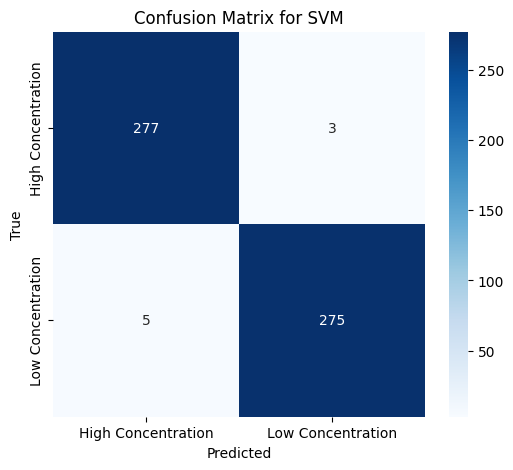

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Feature Scaling
# SVMs are sensitive to the scale of the features, so it's good practice to scale them.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")

# 2. Initialize and Train the SVM Classifier
# Using a Support Vector Classifier (SVC) with a radial basis function (RBF) kernel as a common choice.
svm_model = SVC(kernel='rbf', random_state=42)
print("\nTraining SVM model...")
svm_model.fit(X_train_scaled, y_train)
print("SVM model training complete.")

# 3. Make Predictions
y_pred = svm_model.predict(X_test_scaled)

# 4. Evaluate the Model
print("\n--- SVM Model Evaluation ---")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plotting Confusion Matrix for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for SVM')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

train_pred = svm_model.predict(X_train_scaled)
test_pred = svm_model.predict(X_test_scaled)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

train_f1 = f1_score(y_train, train_pred, pos_label='High Concentration')
test_f1 = f1_score(y_test, test_pred, pos_label='High Concentration')

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)
print("Training F1       :", train_f1)
print("Testing F1        :", test_f1)

print("Accuracy Gap      :", train_acc - test_acc)
print("F1 Gap            :", train_f1 - test_f1)

Training Accuracy: 0.9778571428571429
Testing Accuracy : 0.9857142857142858
Training F1       : 0.9777777777777777
Testing F1        : 0.9857651245551602
Accuracy Gap      : -0.007857142857142896
F1 Gap            : -0.007987346777382442



Training Random Forest model...
Random Forest model training complete.

--- Random Forest Model Evaluation ---
Accuracy: 0.9768

Classification Report:
                    precision    recall  f1-score   support

High Concentration       0.97      0.99      0.98       280
 Low Concentration       0.99      0.96      0.98       280

          accuracy                           0.98       560
         macro avg       0.98      0.98      0.98       560
      weighted avg       0.98      0.98      0.98       560


Confusion Matrix:
[[277   3]
 [ 10 270]]


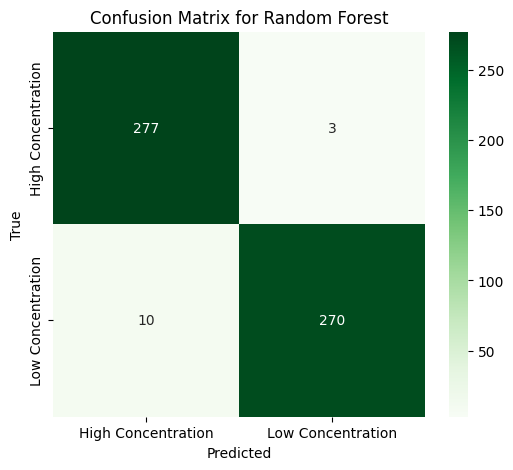

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and Train the Random Forest Classifier
# Using n_estimators=100 (default) and random_state for reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
print("\nTraining Random Forest model...")
rf_model.fit(X_train_scaled, y_train)
print("Random Forest model training complete.")

# Make Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the Model
print("\n--- Random Forest Model Evaluation ---")

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy_rf:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

# Plotting Confusion Matrix for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Random Forest')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

train_pred = rf_model.predict(X_train_scaled)
test_pred = rf_model.predict(X_test_scaled)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

train_f1 = f1_score(y_train, train_pred, pos_label='High Concentration')
test_f1 = f1_score(y_test, test_pred, pos_label='High Concentration')

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)
print("Training F1       :", train_f1)
print("Testing F1        :", test_f1)

print("Accuracy Gap      :", train_acc - test_acc)
print("F1 Gap            :", train_f1 - test_f1)

Training Accuracy: 1.0
Testing Accuracy : 0.9767857142857143
Training F1       : 1.0
Testing F1        : 0.9770723104056437
Accuracy Gap      : 0.023214285714285743
F1 Gap            : 0.022927689594356315


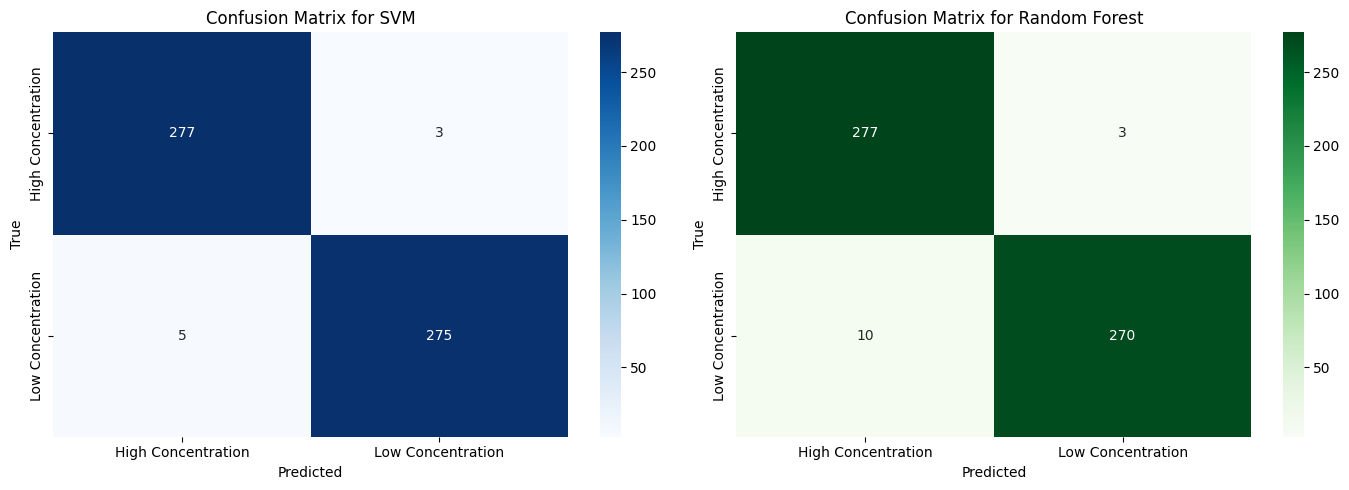

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Confusion Matrix for SVM
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix for SVM')

# Plot Confusion Matrix for Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix for Random Forest')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()


Training XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:47:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model training complete.

--- XGBoost Model Evaluation ---
Accuracy: 0.9839

Classification Report:
                    precision    recall  f1-score   support

High Concentration       0.98      0.99      0.98       280
 Low Concentration       0.99      0.98      0.98       280

          accuracy                           0.98       560
         macro avg       0.98      0.98      0.98       560
      weighted avg       0.98      0.98      0.98       560


Confusion Matrix:
[[276   4]
 [  5 275]]


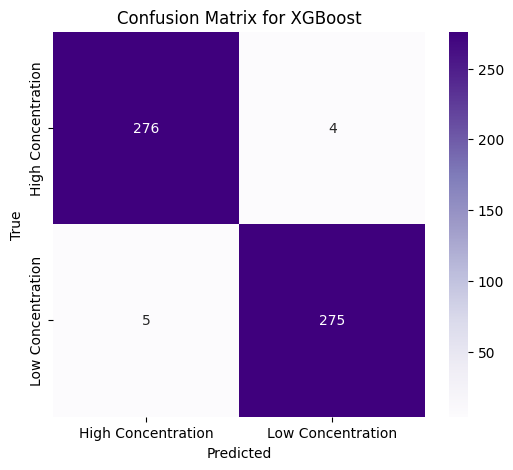

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Encode target labels to numerical values (0 and 1)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Initialize and Train the XGBoost Classifier
# Use 'objective' for binary classification and 'eval_metric' for evaluation
# 'use_label_encoder' is deprecated, so setting it to False is good practice.
xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
print("\nTraining XGBoost model...")
xgb_model.fit(X_train_scaled, y_train_encoded) # Use encoded labels for training
print("XGBoost model training complete.")

# Make Predictions
y_pred_xgb_encoded = xgb_model.predict(X_test_scaled)

# Decode predictions back to original labels for classification report and confusion matrix
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

# Evaluate the Model
print("\n--- XGBoost Model Evaluation ---")

# Accuracy
accuracy_xgb = accuracy_score(y_test_encoded, y_pred_xgb_encoded)
print(f"Accuracy: {accuracy_xgb:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_xgb_encoded, target_names=label_encoder.classes_))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb_encoded)
print(cm_xgb)

# Plotting Confusion Matrix for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for XGBoost')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Predict using the XGBoost model
train_pred = xgb_model.predict(X_train_scaled)
test_pred = xgb_model.predict(X_test_scaled)

# Calculate accuracy using the encoded true labels (y_train_encoded, y_test_encoded)
train_acc = accuracy_score(y_train_encoded, train_pred)
test_acc = accuracy_score(y_test_encoded, test_pred)

# Calculate F1-score using the encoded true labels and the correct numerical pos_label
# From the previous cell (ZVBYfAzI3ve0), 'High Concentration' was encoded as 0 by LabelEncoder
train_f1 = f1_score(y_train_encoded, train_pred, pos_label=0) # Assuming 'High Concentration' is 0
test_f1 = f1_score(y_test_encoded, test_pred, pos_label=0) # Assuming 'High Concentration' is 0

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)
print("Training F1       :", train_f1)
print("Testing F1        :", test_f1)

print("Accuracy Gap      :", train_acc - test_acc)
print("F1 Gap            :", train_f1 - test_f1)

Training Accuracy: 1.0
Testing Accuracy : 0.9839285714285714
Training F1       : 1.0
Testing F1        : 0.983957219251337
Accuracy Gap      : 0.016071428571428625
F1 Gap            : 0.016042780748663055



Training AdaBoost model...
AdaBoost model training complete.

--- AdaBoost Model Evaluation ---
Accuracy: 0.9732

Classification Report:
                    precision    recall  f1-score   support

High Concentration       0.97      0.97      0.97       280
 Low Concentration       0.97      0.97      0.97       280

          accuracy                           0.97       560
         macro avg       0.97      0.97      0.97       560
      weighted avg       0.97      0.97      0.97       560


Confusion Matrix:
[[273   7]
 [  8 272]]


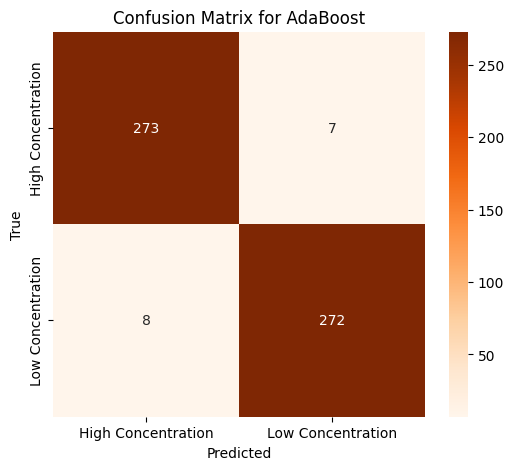

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and Train the AdaBoost Classifier
# Using a DecisionTreeClassifier as the base estimator, which is common for AdaBoost
# The target labels (y_train_encoded, y_test_encoded) are already numerical.
adaboost_model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=42)
print("\nTraining AdaBoost model...")
adaboost_model.fit(X_train_scaled, y_train_encoded)
print("AdaBoost model training complete.")

# Make Predictions
y_pred_ada_encoded = adaboost_model.predict(X_test_scaled)

# Evaluate the Model
print("\n--- AdaBoost Model Evaluation ---")

# Accuracy
accuracy_ada = accuracy_score(y_test_encoded, y_pred_ada_encoded)
print(f"Accuracy: {accuracy_ada:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_ada_encoded, target_names=label_encoder.classes_))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_ada = confusion_matrix(y_test_encoded, y_pred_ada_encoded)
print(cm_ada)

# Plotting Confusion Matrix for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for AdaBoost')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Predict using the XGBoost model
train_pred = adaboost_model.predict(X_train_scaled)
test_pred = adaboost_model.predict(X_test_scaled)

# Calculate accuracy using the encoded true labels (y_train_encoded, y_test_encoded)
train_acc = accuracy_score(y_train_encoded, train_pred)
test_acc = accuracy_score(y_test_encoded, test_pred)

# Calculate F1-score using the encoded true labels and the correct numerical pos_label
# From the previous cell (ZVBYfAzI3ve0), 'High Concentration' was encoded as 0 by LabelEncoder
train_f1 = f1_score(y_train_encoded, train_pred, pos_label=0) # Assuming 'High Concentration' is 0
test_f1 = f1_score(y_test_encoded, test_pred, pos_label=0) # Assuming 'High Concentration' is 0

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)
print("Training F1       :", train_f1)
print("Testing F1        :", test_f1)

print("Accuracy Gap      :", train_acc - test_acc)
print("F1 Gap            :", train_f1 - test_f1)

Training Accuracy: 0.9596428571428571
Testing Accuracy : 0.9732142857142857
Training F1       : 0.9593378913278158
Testing F1        : 0.9732620320855615
Accuracy Gap      : -0.013571428571428568
F1 Gap            : -0.013924140757745729



Training LightGBM model...
[LightGBM] [Info] Number of positive: 1400, number of negative: 1400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000688 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 2800, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM model training complete.

--- LightGBM Model Evaluation ---
Accuracy: 0.9804

Classification Report:
                    precision    recall  f1-score   support

High Concentration       0.98      0.98      0.98       280
 Low Concentration       0.98      0.98      0.98       280

          accuracy                           0.98       560
         macro avg       0.98      0.98      0.98       560
      weighted avg       0.98      0.98      0.98       560


Confusion Matrix:
[[275   5]
 [  6 274]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


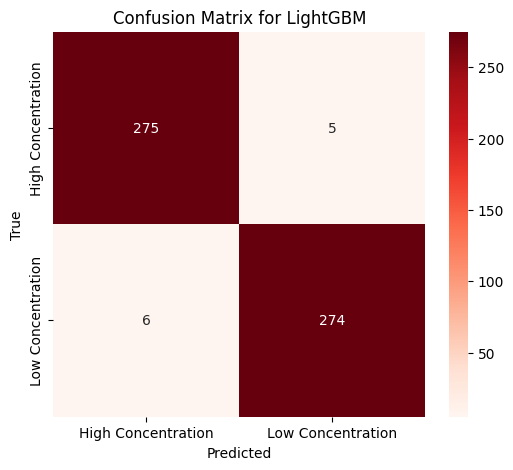

In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and Train the LightGBM Classifier
lgbm_model = lgb.LGBMClassifier(objective='binary', random_state=42)
print("\nTraining LightGBM model...")
lgbm_model.fit(X_train_scaled, y_train_encoded)
print("LightGBM model training complete.")

# Make Predictions
y_pred_lgbm_encoded = lgbm_model.predict(X_test_scaled)

# Evaluate the Model
print("\n--- LightGBM Model Evaluation ---")

# Accuracy
accuracy_lgbm = accuracy_score(y_test_encoded, y_pred_lgbm_encoded)
print(f"Accuracy: {accuracy_lgbm:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_lgbm_encoded, target_names=label_encoder.classes_))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_lgbm = confusion_matrix(y_test_encoded, y_pred_lgbm_encoded)
print(cm_lgbm)

# Plotting Confusion Matrix for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Reds',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for LightGBM')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Predict using the XGBoost model
train_pred = lgbm_model.predict(X_train_scaled)
test_pred = lgbm_model.predict(X_test_scaled)

# Calculate accuracy using the encoded true labels (y_train_encoded, y_test_encoded)
train_acc = accuracy_score(y_train_encoded, train_pred)
test_acc = accuracy_score(y_test_encoded, test_pred)

# Calculate F1-score using the encoded true labels and the correct numerical pos_label
# From the previous cell (ZVBYfAzI3ve0), 'High Concentration' was encoded as 0 by LabelEncoder
train_f1 = f1_score(y_train_encoded, train_pred, pos_label=0) # Assuming 'High Concentration' is 0
test_f1 = f1_score(y_test_encoded, test_pred, pos_label=0) # Assuming 'High Concentration' is 0

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)
print("Training F1       :", train_f1)
print("Testing F1        :", test_f1)

print("Accuracy Gap      :", train_acc - test_acc)
print("F1 Gap            :", train_f1 - test_f1)

Training Accuracy: 1.0
Testing Accuracy : 0.9803571428571428
Training F1       : 1.0
Testing F1        : 0.9803921568627451
Accuracy Gap      : 0.019642857142857184
F1 Gap            : 0.019607843137254943


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Training Gradient Boosting model...
Gradient Boosting model training complete.

--- Gradient Boosting Model Evaluation ---
Accuracy: 0.9750

Classification Report:
                    precision    recall  f1-score   support

High Concentration       0.97      0.98      0.98       280
 Low Concentration       0.98      0.97      0.97       280

          accuracy                           0.97       560
         macro avg       0.98      0.97      0.97       560
      weighted avg       0.98      0.97      0.97       560


Confusion Matrix:
[[275   5]
 [  9 271]]


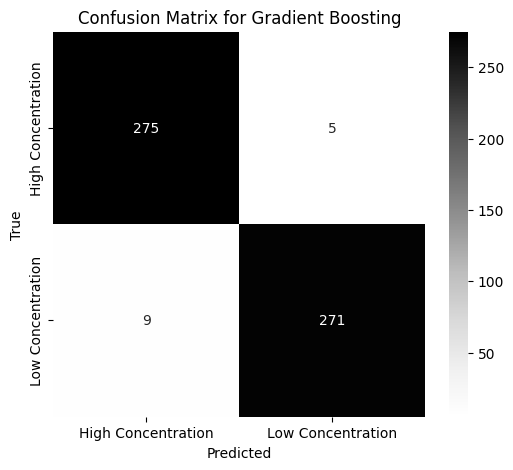

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and Train the Gradient Boosting Classifier
# Use a reasonable number of estimators and learning rate; random_state for reproducibility
gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
print("\nTraining Gradient Boosting model...")
gbc_model.fit(X_train_scaled, y_train_encoded)
print("Gradient Boosting model training complete.")

# Make Predictions
y_pred_gbc_encoded = gbc_model.predict(X_test_scaled)

# Evaluate the Model
print("\n--- Gradient Boosting Model Evaluation ---")

# Accuracy
accuracy_gbc = accuracy_score(y_test_encoded, y_pred_gbc_encoded)
print(f"Accuracy: {accuracy_gbc:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_gbc_encoded, target_names=label_encoder.classes_))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_gbc = confusion_matrix(y_test_encoded, y_pred_gbc_encoded)
print(cm_gbc)

# Plotting Confusion Matrix for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gbc, annot=True, fmt='d', cmap='Greys',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Gradient Boosting')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Predict using the XGBoost model
train_pred = gbc_model.predict(X_train_scaled)
test_pred = gbc_model.predict(X_test_scaled)

# Calculate accuracy using the encoded true labels (y_train_encoded, y_test_encoded)
train_acc = accuracy_score(y_train_encoded, train_pred)
test_acc = accuracy_score(y_test_encoded, test_pred)

# Calculate F1-score using the encoded true labels and the correct numerical pos_label
# From the previous cell (ZVBYfAzI3ve0), 'High Concentration' was encoded as 0 by LabelEncoder
train_f1 = f1_score(y_train_encoded, train_pred, pos_label=0) # Assuming 'High Concentration' is 0
test_f1 = f1_score(y_test_encoded, test_pred, pos_label=0) # Assuming 'High Concentration' is 0

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)
print("Training F1       :", train_f1)
print("Testing F1        :", test_f1)

print("Accuracy Gap      :", train_acc - test_acc)
print("F1 Gap            :", train_f1 - test_f1)

Training Accuracy: 0.9867857142857143
Testing Accuracy : 0.975
Training F1       : 0.9867715409367179
Testing F1        : 0.975177304964539
Accuracy Gap      : 0.011785714285714288
F1 Gap            : 0.011594235972178901
